### Code to look into the databases for the microkinetic model

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
full_path = r"FINAL-Reizmann_AIMNet_Gtotal_msrrho_20C_120C_all_species_new_reduced_all_methods.csv"
df = pd.read_csv(full_path)

full_path_old = r"OLD-Reizmann_AIMNet_Gtotal_msrrho_20C_120C_all_species_new.csv"
df_old = pd.read_csv(full_path_old)

df_reactant9 = pd.read_csv(r"TM9_FINAL\TM9_FINAL\tables\TM9_Gtotal_msrrho_20C_120C_all_species_wide_kcalmol_plus8_species_plus5_SPE-FINAL.csv")

df_reactant8 = pd.read_csv(r"TM8_FINAL\TM8_FINAL\tables\TM8_Gtotal_msrrho_20C_120C_FINAL.csv")

df_BOH3 = pd.read_csv(r"BOH3_neutral_recalc\BOH3_neutral_recalc\tables\BOH3_Gtotal_msrrho_20C_120C_all_species_wide_kcalmol.csv")

In [4]:
df['species_class'].unique()

array(['BOH2Ar', 'BPinAr', 'solution_base_species', 'L', 'OA_TS',
       'OA_product', 'OA_reactant', 'PdL2', 'PdLArOH', 'PdL', 'Pinacol',
       'Substrate', 'TM_TS', 'TM_product', 'TM_reactant',
       'TM_reactant_10'], dtype=object)

In [5]:
len(df['species_class'].unique())

16

In [6]:
df['species_name'].unique()

array(['BOH2Ar_compound_2_as_BOH2_35-dimethylisoxazole-4-boronic_acid',
       'BOH2Ar_compound_6_benzofuran-2-boronic_acid',
       'BOH2Ar_compound_9_as_BOH2_1-Boc-pyrrole-2-boronic_acid',
       'BPinAr_compound_2_as_BPin_35-dimethylisoxazole-4-boronate',
       'BPinAr_compound_6_benzofuran-2-boronate',
       'BPinAr_compound_9_as_BPin_1-Boc-pyrrole-2-boronate', 'Br_minus',
       'Cl_minus', 'DBUH_Br_thf', 'DBUH_Cl_thf', 'DBUH_plus_thf',
       'DBU_thf', 'H2O', 'HBr', 'HCl', 'L_Mono_AmPhos',
       'L_Mono_Catacxium_A', 'L_Mono_PCy3', 'L_Mono_PPh3', 'L_Mono_PoTol',
       'L_Mono_RuPhos', 'L_Mono_SPhos', 'L_Mono_XPhos', 'L_Mono_tBu3',
       'L_Xantphos_Xantphos', 'OA_TS_2_chloropyridine_Displaced_AmPhos',
       'OA_TS_2_chloropyridine_Displaced_Catacxium_A',
       'OA_TS_2_chloropyridine_Displaced_PCy3',
       'OA_TS_2_chloropyridine_Displaced_PPh3',
       'OA_TS_2_chloropyridine_Displaced_PoTol',
       'OA_TS_2_chloropyridine_Displaced_RuPhos',
       'OA_TS_2_chloropyrid

### Settings

In [7]:
# Unless otherwise defined, these are the settings used for testing the barriers
substrate = "3_bromoquinoline"   # case1 substrate
ligand    = "PCy3"               # ligand
T         = 110               # temperature in Celsius
case      = "case1"
ligand_list = ["PCy3", "PPh3", "AmPhos", "Catacxium_A", "RuPhos", "SPhos", "tBu3", "XPhos"]
substrate_list = ["3_bromoquinoline", "2_chloropyridine", "3_chloropyridine"]
temperature_list = [30, 50, 70, 90, 110]
case_list = ["case1", "case2", "case3", "case4"]
dict_tm_case = {
    'case1': ('3_bromoquinoline', 'BOH2Ar_compound_2_as_BOH2_35-dimethylisoxazole-4-boronic_acid', 'BPinAr_compound_2_as_BPin_35-dimethylisoxazole-4-boronate'),
    'case2': ('3_chloropyridine', 'BOH2Ar_compound_2_as_BOH2_35-dimethylisoxazole-4-boronic_acid', 'BPinAr_compound_2_as_BPin_35-dimethylisoxazole-4-boronate'),
    'case3': ('3_chloropyridine', 'BOH2Ar_compound_6_benzofuran-2-boronic_acid', 'BPinAr_compound_6_benzofuran-2-boronate'),
    'case4': ('2_chloropyridine', 'BOH2Ar_compound_9_as_BOH2_1-Boc-pyrrole-2-boronic_acid', 'BPinAr_compound_9_as_BPin_1-Boc-pyrrole-2-boronate'),
}

### Functions

In [8]:
# Helper: look up G for a species at a given temperature
def get_G(df, species_name, temperature_C):
    row = df[(df["species_name"] == species_name) & (df["temperature_C"] == temperature_C)]
    if row.empty:
        raise ValueError(f"Species {species_name!r} not found at {temperature_C} C")
    return row["G_total_wb97mv_plus_Gcorr_plus_SMDTHF_kcal_mol"].values[0] 

def get_G_old(df_old, species_name, temperature_C):
    row = df_old[(df_old["species_name"] == species_name) & (df_old["temperature_C"] == temperature_C)]
    if row.empty:
        raise ValueError(f"Species {species_name!r} not found at {temperature_C} C")
    return row["G_total_AIMNet_msrrho_kcal_mol"].values[0] # Before: G_total_wb97mv_plus_Gcorr_plus_SMDTHF_kcal_mol

def get_G_reactant9(df_reactant9, species_name, temperature_C):
    row = df_reactant9[(df_reactant9["species"] == species_name) & (df_reactant9["temperature_C"] == temperature_C)]
    if row.empty:
        raise ValueError(f"Species {species_name!r} not found at {temperature_C} C")
    return row["Gtotal_wB97MV_gas_SPE_AIMNet2PD_msRRHO_Gsolv_THF_kcal_mol"].values[0]

def get_G_reactant8(df_reactant8, species_name, temperature_C):
    row = df_reactant8[(df_reactant8["species"] == species_name) & (df_reactant8["temperature_C"] == temperature_C)]
    if row.empty:
        raise ValueError(f"Species {species_name!r} not found at {temperature_C} C")
    return row["Gtotal_wB97MV_gas_SPE_AIMNet2PD_msRRHO_Gsolv_THF_kcal_mol"].values[0] # Before: G_total_wb97mv_plus_Gcorr_plus_SMDTHF_kcal_mol

def get_G_BOH3(df_BOH3, species_name, temperature_C):
    row = df_BOH3[(df_BOH3["species"] == species_name) & (df_BOH3["temperature_C"] == temperature_C)]
    if row.empty:
        raise ValueError(f"Species {species_name!r} not found at {temperature_C} C")
    return row["Gtotal_wB97MV_gas_SPE_AIMNet2PD_msRRHO_Gsolv_THF_kcal_mol"].values[0] 

# Plotting function for the OA
def plotting_OA_barriers(substrate, ligand, T, scenario="Scenario_2"):
    results_ligand = OA_barriers(substrate, ligand, T)
    labels   = ["PdL2 + Sub\n(resting)", "OA_reactant\n+ L", "OA_TS\n+ L", "OA_product\n+ L"]
    energies = [0.0, results_ligand[scenario]["dG_OA_reactant"], results_ligand[scenario]["dG_OA_TS"], results_ligand[scenario]["dG_OA_product"]]
    x = [0, 1, 2, 3]

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(x, energies, "o-", color="steelblue", linewidth=2, markersize=8)
    for xi, yi, lbl in zip(x, energies, labels):
        ax.annotate(f"{lbl}\n{yi:+.1f} kcal/mol", (xi, yi),
                    textcoords="offset points", xytext=(0, 14),
                    ha="center", fontsize=8.5)
    ax.axhline(0, color="grey", linestyle="--", linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(["PdL2+Sub", "OA_react+L", "OA_TS+L", "OA_prod+L"], fontsize=9)
    ax.set_ylabel("dG (kcal/mol)")
    ax.set_ylim(min(energies)-5, max(energies)+10)
    ax.set_title(f"OA Energy Profile {scenario}: {substrate} / {ligand} @ {T} C")
    plt.tight_layout()
    plt.show()

def plotting_TM_barriers(ligand, case, T, scenario="Scenario_2"):
    substrate = dict_tm_case[case][0]
    results_ligand = TM_barriers(ligand, case, T)
    if scenario == "Scenario_1":
       labels_tm   = ["PdLArOH + BOH2Ar\n(ref)", "TM_reactant_10", "TM_reactant", "TM_TS", "TM_product\n+ BOH3"]
       energies_tm = [0.0, results_ligand[scenario]["dG_TM_reactant_10"], results_ligand[scenario]["dG_TM_reactant"], results_ligand[scenario]["dG_TM_TS"], results_ligand[scenario]["dG_TM_product"]]
       x = [0, 1, 2, 3, 4]

       fig, ax = plt.subplots(figsize=(8, 4))
       ax.plot(x, energies_tm, "o-", color="darkorange", linewidth=2, markersize=8)
       for xi, yi, lbl in zip(x, energies_tm, labels_tm):
            ax.annotate(f"{lbl}\n{yi:+.1f}", (xi, yi),
                        textcoords="offset points", xytext=(0, 14), ha="center", fontsize=8.5)
       ax.axhline(0, color="grey", linestyle="--", linewidth=0.8)
       ax.set_xticks(x)
       ax.set_xticklabels(labels_tm, fontsize=9)
       ax.set_ylabel("dG (kcal/mol)")
       ax.set_ylim(min(energies_tm)-5, max(energies_tm)+5)
       ax.set_title(f"TM Energy Profile: {case} / {ligand} @ {T} C")
       plt.tight_layout()
       plt.show()
 
    else:
        labels   = ["PdLArOH + BPin + 2H2O\n(ref)", "TM_reactant\n+ pinacol", "TM_TS\n+ pinacol", "TM_prod\n+ pinacol + B(OH)3"]
        energies = [0.0, results_ligand[scenario]["dG_TM_reactant"], results_ligand[scenario]["dG_TM_TS"], results_ligand[scenario]["dG_TM_product"]]
        x = [0, 1, 2, 3]

        fig, ax = plt.subplots(figsize=(8, 4))
        ax.plot(x, energies, "o-", color="steelblue", linewidth=2, markersize=8)
        for xi, yi, lbl in zip(x, energies, labels):
            ax.annotate(f"{lbl}\n{yi:+.1f} kcal/mol", (xi, yi),
                        textcoords="offset points", xytext=(0, 14),
                        ha="center", fontsize=8.5)
        ax.axhline(0, color="grey", linestyle="--", linewidth=0.8)
        ax.set_xticks(x)
        ax.set_xticklabels(["PdLArOH+BPin+2H2O", "TM_react+pinacol", "TM_TS+pinacol", "TM_prod+pinacol+B(OH)3"], fontsize=9)
        ax.set_ylabel("dG (kcal/mol)")
        ax.set_ylim(min(energies)-5, max(energies)+10)
        ax.set_title(f"TM Energy Profile {scenario}: {substrate} / {ligand} @ {T} C ({case})")
        plt.tight_layout()
        plt.show()

def plotting_TM_barriers_with_react9(ligand, case, T, scenario="Scenario_2"):
    substrate = dict_tm_case[case][0]
    results_ligand = TM_barriers_with_react9(ligand, case, T)
    if scenario == "Scenario_1":
       labels_tm   = ["TM_reactant8 + \n 2 x R2B(OH)2", "TM_reactant_9", "TM_reactant_10", "TM_reactant", "TM_TS", "TM_product\n+ BOH3"]
       energies_tm = [0.0, results_ligand[scenario]["dG_TM_reactant_9"], results_ligand[scenario]["dG_TM_reactant_10"], results_ligand[scenario]["dG_TM_reactant"], results_ligand[scenario]["dG_TM_TS"], results_ligand[scenario]["dG_TM_product"]]
       x = [0, 1, 2, 3, 4, 5]

       fig, ax = plt.subplots(figsize=(8, 4))
       ax.plot(x, energies_tm, "o-", color="darkorange", linewidth=2, markersize=8)
       for xi, yi, lbl in zip(x, energies_tm, labels_tm):
            ax.annotate(f"{lbl}\n{yi:+.1f}", (xi, yi),
                        textcoords="offset points", xytext=(0, 14), ha="center", fontsize=8.5)
       ax.axhline(0, color="grey", linestyle="--", linewidth=0.8)
       ax.set_xticks(x)
       ax.set_xticklabels(labels_tm, fontsize=9)
       ax.set_ylabel("dG (kcal/mol)")
       ax.set_ylim(min(energies_tm)-5, max(energies_tm)+5)
       ax.set_title(f"TM Energy Profile: {case} / {ligand} @ {T} C")
       plt.tight_layout()
       plt.show()
 
    else:
        labels   = ["PdLArOH + BPin + 2H2O\n(ref)", "TM_reactant\n+ pinacol", "TM_TS\n+ pinacol", "TM_prod\n+ pinacol + B(OH)3"]
        energies = [0.0, results_ligand[scenario]["dG_TM_reactant"], results_ligand[scenario]["dG_TM_TS"], results_ligand[scenario]["dG_TM_product"]]
        x = [0, 1, 2, 3]

        fig, ax = plt.subplots(figsize=(8, 4))
        ax.plot(x, energies, "o-", color="steelblue", linewidth=2, markersize=8)
        for xi, yi, lbl in zip(x, energies, labels):
            ax.annotate(f"{lbl}\n{yi:+.1f} kcal/mol", (xi, yi),
                        textcoords="offset points", xytext=(0, 14),
                        ha="center", fontsize=8.5)
        ax.axhline(0, color="grey", linestyle="--", linewidth=0.8)
        ax.set_xticks(x)
        ax.set_xticklabels(["PdLArOH+BPin+2H2O", "TM_react+pinacol", "TM_TS+pinacol", "TM_prod+pinacol+B(OH)3"], fontsize=9)
        ax.set_ylabel("dG (kcal/mol)")
        ax.set_ylim(min(energies)-5, max(energies)+10)
        ax.set_title(f"TM Energy Profile {scenario}: {substrate} / {ligand} @ {T} C ({case})")
        plt.tight_layout()
        plt.show()

## Oxidative Addition (OA) Barrier Calculation


| Scenario | Reference state | Formula |
|---|---|---|
| PdL resting state | PdL + Sub | `G(OA_TS) - G(PdL) - G(Sub)` |
| PdL2 resting state | PdL2 + Sub (L is released) | `G(OA_TS) + G(L) - G(PdL2) - G(Sub)` |


In [9]:
def OA_barriers(substrate, ligand, T, verbose=False):
    if substrate == "3_bromoquinoline":
        substrate_capitalized = "3_Bromoquinoline"
    elif substrate == "2_chloropyridine":
        substrate_capitalized = "2_chloropyridine"
        substrate = "2_chloropyridine_concerted" # 2_chloropyridine_Displaced 2_chloropyridine_concerted
    else:
        substrate_capitalized = substrate 
    
    # Fetch free energies
    G_PdL2      = get_G(df, f"PdL2_Mono_{ligand}",                       T)  # Pd(L)2 resting state
    G_PdL       = get_G(df, f"PdL_Mono_{ligand}",                        T)  # Pd(L) monoligated
    G_L         = get_G(df, f"L_Mono_{ligand}",                          T)  # free ligand
    G_Substrate = get_G(df, f"Substrate_Reizman_{substrate_capitalized}",         T)
    G_OA_react  = get_G(df, f"OA_reactant_{substrate}_{ligand}",         T)
    G_OA_TS     = get_G(df, f"OA_TS_{substrate}_{ligand}",               T)
    G_OA_prod   = get_G(df, f"OA_product_{substrate}_{ligand}",          T)

    # L dissociation energy: PdL2 -> PdL + L
    dG_L_dissoc = G_PdL + G_L - G_PdL2

    # Scenario 1: PdL as resting state
    # Atom balance: OA_TS = Pd + L + Sub  |  ref = PdL + Sub  (OK)
    G_ref_PdL       = G_PdL + G_Substrate
    dG_OA_react_sc1 = G_OA_react - G_ref_PdL
    dG_OA_TS_sc1    = G_OA_TS    - G_ref_PdL
    dG_OA_prod_sc1  = G_OA_prod  - G_ref_PdL
    total_barrier_sc1 = max(dG_OA_TS_sc1, dG_OA_TS_sc1 - dG_OA_react_sc1)

    # Scenario 2: PdL2 as resting state, one L is released to solution
    # Atom balance: OA_TS + L = Pd + 2L + Sub  |  ref = PdL2 + Sub  (OK)
    G_ref_PdL2      = G_PdL2 + G_Substrate
    dG_OA_react_sc2 = (G_OA_react + G_L) - G_ref_PdL2
    dG_OA_TS_sc2    = (G_OA_TS    + G_L) - G_ref_PdL2
    dG_OA_prod_sc2  = (G_OA_prod  + G_L) - G_ref_PdL2
    total_barrier_sc2 = max(dG_OA_TS_sc2, dG_OA_TS_sc2 - dG_OA_react_sc2)

    if verbose == True:
        print(f"OA Barrier Calculation: {substrate} / {ligand} @ {T} C")
        print("=" * 60)
        print(f"  L dissociation (PdL2 -> PdL + L): {dG_L_dissoc:+.2f} kcal/mol")
        print()
        print("Scenario 1: PdL resting state (ref = PdL + Sub):")
        print(f"  dG(OA_reactant) : {dG_OA_react_sc1:+.2f} kcal/mol")
        print(f"  dG(OA_TS)       : {dG_OA_TS_sc1:+.2f} kcal/mol")
        print(f"  dG(OA_product)  : {dG_OA_prod_sc1:+.2f} kcal/mol")
        print(f"  Total barrier (max of TS or TS - reactant): {total_barrier_sc1:+.2f} kcal/mol")
        print()
        print("Scenario 2: PdL2 resting state (ref = PdL2 + Sub, L released):")
        print(f"  dG(OA_reactant) : {dG_OA_react_sc2:+.2f} kcal/mol")
        print(f"  dG(OA_TS)       : {dG_OA_TS_sc2:+.2f} kcal/mol")
        print(f"  dG(OA_product)  : {dG_OA_prod_sc2:+.2f} kcal/mol")
        print(f"  Total barrier (max of TS or TS - reactant): {total_barrier_sc2:+.2f} kcal/mol")

    return {
        "L_dissoc": dG_L_dissoc,
        "Scenario_1": {
            "dG_OA_reactant": dG_OA_react_sc1,
            "dG_OA_TS": dG_OA_TS_sc1,
            "dG_OA_product": dG_OA_prod_sc1,
            'total_barrier': total_barrier_sc1
        },
        "Scenario_2": {
            "dG_OA_reactant": dG_OA_react_sc2,
            "dG_OA_TS": dG_OA_TS_sc2,
            "dG_OA_product": dG_OA_prod_sc2,
            'total_barrier': total_barrier_sc2
        }
    }

# OA_barriers(substrate, ligand, T)
results_all_ligands_OA = {(ligand, substrate): OA_barriers(substrate, ligand, T) for ligand in ligand_list for substrate in substrate_list}

In [9]:
# Code that iterates over all temperatures, substrates and ligands, collects the OA barriers for both scenarios, and stores them in a DataFrame for further analysis or plotting
df_OA_barriers = pd.DataFrame()

rows = []

for temperature in temperature_list:
    results_all_ligands_OA = {(ligand, substrate): OA_barriers(substrate, ligand, temperature) for ligand in ligand_list for substrate in substrate_list}
    print(f"\nCompleted OA barrier calculations for T = {temperature} C")
    for (ligand, substrate), results in results_all_ligands_OA.items():
        print(f"\n=== {substrate} / {ligand} @ {temperature} C ===")
        print("Scenario 1: PdL resting state (ref = PdL + Sub):")
        print(f"  Total barrier (max of TS or TS - reactant): {results['Scenario_1']['total_barrier']:+.2f} kcal/mol")
        print("Scenario 2: PdL2 resting state (ref = PdL2 + Sub, L released):")
        print(f"  Total barrier (max of TS or TS - reactant): {results['Scenario_2']['total_barrier']:+.2f} kcal/mol")
        rows.append({
            "temp_C": temperature,
            "substrate": substrate,
            "ligand": ligand,
            "OA_barrier_scenario_1": results['Scenario_1']['total_barrier'],
            "OA_barrier_scenario_2": results['Scenario_2']['total_barrier']
        })

df_OA_barriers = pd.concat([df_OA_barriers, pd.DataFrame(rows)], ignore_index=True)


Completed OA barrier calculations for T = 30 C

=== 3_bromoquinoline / PCy3 @ 30 C ===
Scenario 1: PdL resting state (ref = PdL + Sub):
  Total barrier (max of TS or TS - reactant): +7.70 kcal/mol
Scenario 2: PdL2 resting state (ref = PdL2 + Sub, L released):
  Total barrier (max of TS or TS - reactant): +28.94 kcal/mol

=== 2_chloropyridine / PCy3 @ 30 C ===
Scenario 1: PdL resting state (ref = PdL + Sub):
  Total barrier (max of TS or TS - reactant): +19.92 kcal/mol
Scenario 2: PdL2 resting state (ref = PdL2 + Sub, L released):
  Total barrier (max of TS or TS - reactant): +44.74 kcal/mol

=== 3_chloropyridine / PCy3 @ 30 C ===
Scenario 1: PdL resting state (ref = PdL + Sub):
  Total barrier (max of TS or TS - reactant): +10.51 kcal/mol
Scenario 2: PdL2 resting state (ref = PdL2 + Sub, L released):
  Total barrier (max of TS or TS - reactant): +35.33 kcal/mol

=== 3_bromoquinoline / PPh3 @ 30 C ===
Scenario 1: PdL resting state (ref = PdL + Sub):
  Total barrier (max of TS or TS - r

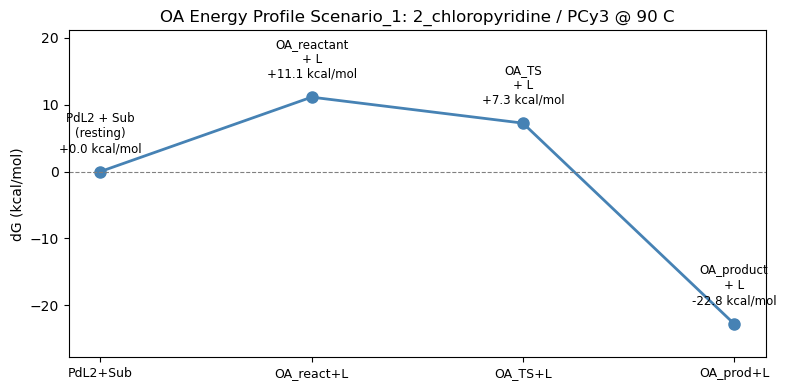

In [9]:
# Plotting scenario 1 or 2 for a specific substrate, ligand and temperature.
# Note: the names of the axis and bullets don't match
plotting_OA_barriers(substrate="2_chloropyridine", ligand="PCy3", T=90, scenario="Scenario_1")